In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
import shap
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [ ]:
df = pd.read_csv("../dataset/student.csv")
print(f"✓ Dataset loaded successfully: {df.shape[0]} rows, {df.shape[1]} columns")

✓ Dataset loaded successfully: 1044 rows, 33 columns


In [3]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [4]:
# Simplified preprocessing (fixed order for dummies and drop)
for col in ["Mjob", "Fjob", "reason", "guardian"]:
    dummies = pd.get_dummies(df[col], prefix=col)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)

df = df.drop(columns=["school", "address"])

df["sex_male"] = df["sex"] == "M"
df["parent_together"] = df["Pstatus"] == "T"

mapping = {1: 60, 2: 210, 3: 450, 4: 720}
df["traveltime_minutes"] = df["traveltime"].map(mapping)
df["studytime_minutes"] = df["studytime"].map(mapping)

for col in ["schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]:
    df[col] = df[col] == "yes"

for col in ["G1", "G2", "G3"]:
    df[col] = df[col] * 5


df["avg_parent_edu"] = (df["Medu"] + df["Fedu"]) / 2
support_cols = ["schoolsup", "famsup", "paid"]
df[support_cols] = df[support_cols].astype(int)
df["total_support"] = df["schoolsup"] + df["famsup"] + df["paid"]
df["study_per_travel"] = df["studytime_minutes"] / (df["traveltime_minutes"] + 1)

df = df.drop(columns=["schoolsup", "famsup", "paid", "studytime_minutes", "traveltime_minutes", "studytime", "Medu", "Fedu"])

In [5]:
X = df.drop(columns=["G3"]).select_dtypes(include=[np.number])
y = df["G3"]

# Feature selection with n_jobs=1 to avoid nested parallelism
print("\n=== FEATURE SELECTION ===")
selector = SelectFromModel(
    RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1), 
    threshold="median"
)
selector.fit(X, y)
X_selected = selector.transform(X)
print(f"Selected {X_selected.shape[1]} features from {X.shape[1]} total features")

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Random Forest model with safety settings for laptop (n_jobs=1)
print("\n=== RANDOM FOREST REGRESSOR ===")
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=1  # Avoid nested parallelism on laptop
)
model.fit(X_train, y_train)

# Cross-validation with n_jobs=1
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_squared_error", n_jobs=1)
print(f"CV RMSE: {np.sqrt(-cv_scores).mean():.4f} (±{np.sqrt(-cv_scores).std():.4f})")

# Evaluation on test set
y_pred = model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rf_r2 = r2_score(y_test, y_pred)
rf_mae = mean_absolute_error(y_test, y_pred)
print(f"Test RMSE: {rf_rmse:.4f}")
print(f"Test R²: {rf_r2:.4f}")
print(f"Test MAE: {rf_mae:.4f}")


=== FEATURE SELECTION ===
Selected 8 features from 15 total features

=== RANDOM FOREST REGRESSOR ===
CV RMSE: 6.9998 (±1.3651)
Test RMSE: 8.2420
Test R²: 0.8243
Test MAE: 4.6997


In [6]:
print("\n=== TRAINING PERFORMANCE ===")
y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
print(f"Train R²: {train_r2:.4f}")
print(f"Test R²: {rf_r2:.4f}")

# Check for overfitting
overfitting_gap = train_r2 - rf_r2
if overfitting_gap > 0.15:
    print(f"⚠ Potential overfitting detected: {overfitting_gap:.4f} gap between train and test R²")
else:
    print(f"✓ Model generalization is good: {overfitting_gap:.4f} gap")


=== TRAINING PERFORMANCE ===
Train R²: 0.9502
Test R²: 0.8243
✓ Model generalization is good: 0.1259 gap


In [7]:
def regression_accuracy(y_true, y_pred, tolerance=5):
    """
    Calculate the percentage of predictions within ±tolerance of actual value.
    
    Parameters:
    -----------
    y_true : array-like
        Actual values
    y_pred : array-like
        Predicted values
    tolerance : float, default=5
        Tolerance range (±) for considering a prediction as accurate
    
    Returns:
    --------
    float : Percentage of accurate predictions within tolerance
    """
    correct = abs(y_true - y_pred) <= tolerance
    return correct.mean() * 100

print("\n=== PREDICTION ACCURACY (Random Forest) ===")
acc_5 = regression_accuracy(y_test, y_pred, tolerance=5)
acc_10 = regression_accuracy(y_test, y_pred, tolerance=10)

print(f"Accuracy (±5 units): {acc_5:.2f}%")
print(f"Accuracy (±10 units): {acc_10:.2f}%")


=== PREDICTION ACCURACY (Random Forest) ===
Accuracy (±5 units): 70.33%
Accuracy (±10 units): 93.30%


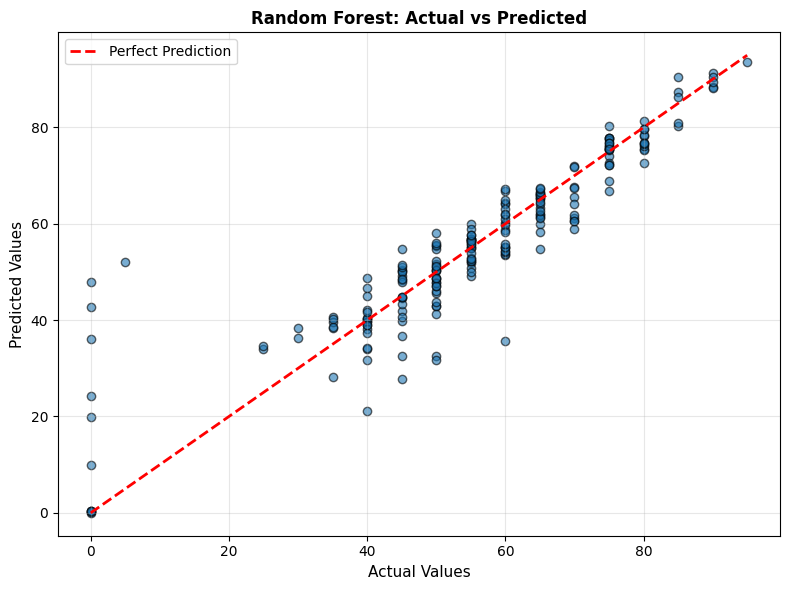

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
# Add diagonal line for perfect predictions
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel("Actual Values", fontsize=11)
plt.ylabel("Predicted Values", fontsize=11)
plt.title("Random Forest: Actual vs Predicted", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
# XGBoost model with safety settings (n_jobs=1)
print("\n=== XGBOOST REGRESSOR ===")
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42,
    n_jobs=1,  # Avoid nested parallelism on laptop
    verbosity=0
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2 = r2_score(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
print(f"Test RMSE: {xgb_rmse:.4f}")
print(f"Test R²: {xgb_r2:.4f}")
print(f"Test MAE: {xgb_mae:.4f}")

# Model comparison
print("\n=== MODEL COMPARISON ===")
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'RMSE': [rf_rmse, xgb_rmse],
    'R²': [rf_r2, xgb_r2],
    'MAE': [rf_mae, xgb_mae]
})
print(comparison.to_string(index=False))
best_model = 'XGBoost' if xgb_r2 > rf_r2 else 'Random Forest'
print(f"\n✓ Best model: {best_model}")


=== XGBOOST REGRESSOR ===
Test RMSE: 8.6276
Test R²: 0.8074
Test MAE: 5.0873

=== MODEL COMPARISON ===
        Model     RMSE       R²      MAE
Random Forest 8.242014 0.824250 4.699744
      XGBoost 8.627558 0.807423 5.087321

✓ Best model: Random Forest



=== FEATURE IMPORTANCE ===


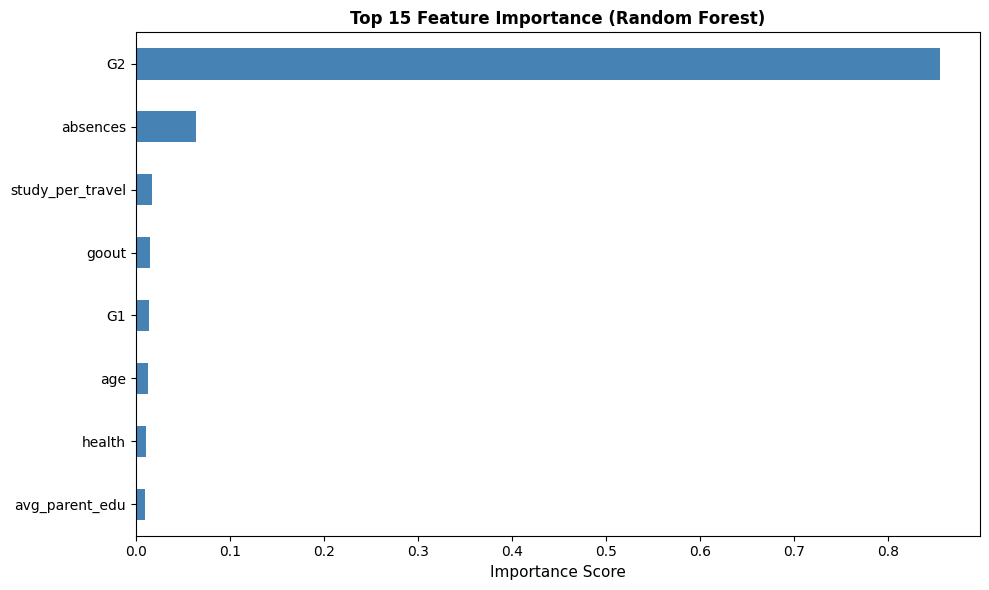


Top 5 Most Important Features:
  1. G2: 0.8555
  2. absences: 0.0642
  3. study_per_travel: 0.0176
  4. goout: 0.0151
  5. G1: 0.0139


In [10]:
print("\n=== FEATURE IMPORTANCE ===")
# Feature importance plot for selected features
importances = model.feature_importances_
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
feat_imp = pd.Series(importances, index=selected_features).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.head(15).plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel("Importance Score", fontsize=11)
ax.set_title("Top 15 Feature Importance (Random Forest)", fontsize=12, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTop 5 Most Important Features:")
for i, (feat, imp) in enumerate(feat_imp.head(5).items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")


=== SHAP ANALYSIS ===
Computing SHAP values for model interpretation...

SHAP Summary Plot (Bar) - Average |SHAP| values:


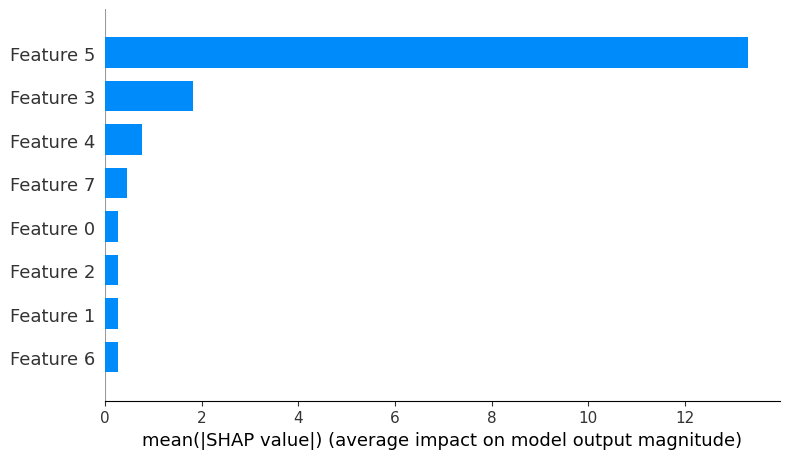

<Figure size 640x480 with 0 Axes>


SHAP Summary Plot (Scatter) - Individual prediction impacts:


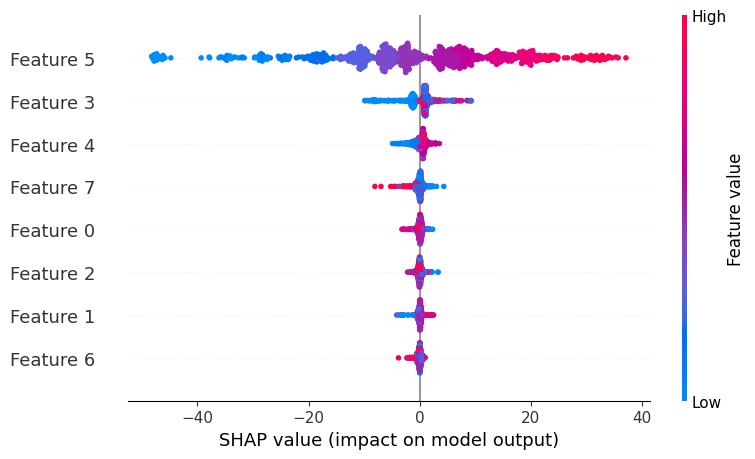

<Figure size 640x480 with 0 Axes>

In [11]:
print("\n=== SHAP ANALYSIS ===")
print("Computing SHAP values for model interpretation...")

# Use only the features actually used in the model (after selection)
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# Summary plot for feature importance
print("\nSHAP Summary Plot (Bar) - Average |SHAP| values:")
shap.summary_plot(shap_values, X_train, plot_type="bar")
plt.tight_layout()
plt.show()

print("\nSHAP Summary Plot (Scatter) - Individual prediction impacts:")
shap.summary_plot(shap_values, X_train)
plt.tight_layout()
plt.show()


=== INDIVIDUAL PREDICTION EXPLANATION ===
SHAP Force Plot for the first training sample:

Actual value: 55.00
Predicted value: 51.03



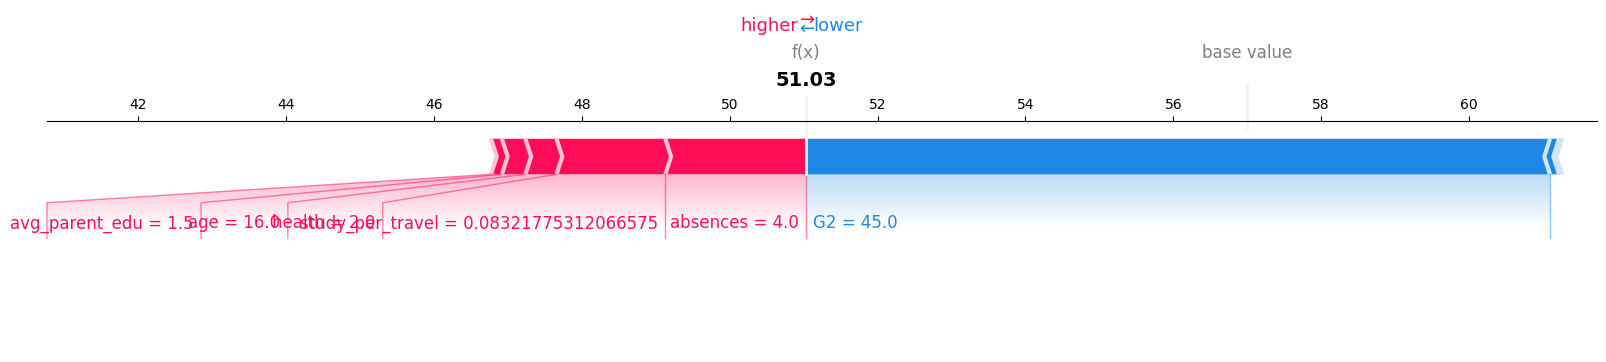

<Figure size 640x480 with 0 Axes>

In [12]:
print("\n=== INDIVIDUAL PREDICTION EXPLANATION ===")
print("SHAP Force Plot for the first training sample:")

selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
X_train_df = pd.DataFrame(X_train, columns=selected_features)

print(f"\nActual value: {y_train.iloc[0]:.2f}")
print(f"Predicted value: {model.predict(X_train[0:1])[0]:.2f}\n")

shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_train_df.iloc[0],
    matplotlib=True
)
plt.tight_layout()
plt.show()

In [13]:
print("\n=== PREDICTION INTERPRETATION ===")

def explain_prediction(shap_values, features, threshold=0.01):
    """
    Generate a human-readable explanation of individual prediction contributions.
    
    Parameters:
    -----------
    shap_values : array-like
        SHAP values for a single prediction
    features : array-like
        Feature names
    threshold : float
        Minimum |SHAP| value to include in explanation
    
    Returns:
    --------
    str : Human-readable explanation
    """
    explanation = []
    for i, feat in enumerate(features):
        if abs(shap_values[i]) > threshold:
            direction = "↑ increases" if shap_values[i] > 0 else "↓ decreases"
            explanation.append(f"  • {feat} {direction} prediction (+{shap_values[i]:.3f})")
    return "\n".join(explanation)

# Use only selected features
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask].tolist()

print(f"\nSample #1 Prediction Breakdown:")
print(f"  Actual: {y_train.iloc[0]:.2f}")
print(f"  Predicted: {model.predict(X_train[0:1])[0]:.2f}")
print(f"  Key contributors:")
explanation = explain_prediction(shap_values[0], selected_features)
if explanation:
    print(explanation)
else:
    print("  (No significant contributors above threshold)")


=== PREDICTION INTERPRETATION ===

Sample #1 Prediction Breakdown:
  Actual: 55.00
  Predicted: 51.03
  Key contributors:
  • age ↑ increases prediction (+0.318)
  • goout ↓ decreases prediction (+-0.123)
  • health ↑ increases prediction (+0.421)
  • absences ↑ increases prediction (+1.902)
  • G1 ↓ decreases prediction (+-0.042)
  • G2 ↓ decreases prediction (+-10.066)
  • avg_parent_edu ↑ increases prediction (+0.147)
  • study_per_travel ↑ increases prediction (+1.472)
